In [146]:
from May31_Frank2D_CPU import *

In [147]:
import numpy as np
import matplotlib.pyplot as plt
from constants import rad_to_arcsec, deg_to_rad
from scipy.stats import binned_statistic
from matplotlib.colors import LogNorm
from matplotlib.ticker import MaxNLocator

# frank1d utilities
from frank.geometry import SourceGeometry
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner
import matplotlib.colors as colors

class Plot(object):
    def __init__(self, Frank2D, Geometry):
        self._frank2d = Frank2D
        self._Geometry = Geometry
        self._u_gridded, self._v_gridded = self._frank2d._gridded_data['u'], self._frank2d._gridded_data['v']
        self._vis_gridded, self._weights_gridded = self._frank2d._gridded_data['vis'], self._frank2d._gridded_data['weights']
        self._Nx = Frank2D._Nx
        self._Ny = Frank2D._Ny

        
    def intensity_model(self, title="Frank2D intensity model", deproject = False, fig_size = 6, vmin = 0, vmax = 1e11):
        frank2d = self._frank2d

        I = frank2d.sol_intensity

        x_ = frank2d._FT._Xn * rad_to_arcsec
        y_ = frank2d._FT._Yn * rad_to_arcsec
        Nx, Ny = self._Nx, self._Ny
        x, y = x_, y_

        # Deprojection.
        inc_r = self._Geometry._inc * deg_to_rad
        pa_r = self._Geometry._pa * deg_to_rad

        cos_i = np.cos(inc_r)
        cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)
        
        if deproject:
            x = (x_ * cos_pa + y_ * sin_pa) / cos_i
            y = (x_ * -sin_pa + y_ * cos_pa)

        plt.figure(figsize=(fig_size, fig_size))

        X = x.reshape(Ny, Nx)
        Y = y.reshape(Ny, Nx)
        I = I.reshape(Ny, Nx)

        I_flip = np.fliplr(I)
        X_flip = -np.fliplr(X)

        norm = colors.PowerNorm(gamma=0.45, vmin=vmin, vmax=vmax)
        plot = plt.pcolormesh(X_flip, Y, I_flip,
                              cmap='magma',norm=norm)

        cmap = plt.colorbar(plot, shrink=0.8)
        cmap.set_label(r' $I_{\nu}$ [Jy $sr^{-1}$]', size=10)

        plt.title(title)
        plt.xlabel(r'$\Delta\alpha$ ["]')
        plt.ylabel(r'$\Delta\delta$ ["]')

        plt.gca().set_aspect(1)  


        plt.xlim(2, -2)
        plt.ylim(-2, 2)
        plt.xticks([2, 1, 0, -1, -2])
        plt.yticks([-2, -1, 0, 1, 2])


        plt.show()
        return I_flip, X, Y

    def given_intensity_model(self, I, N, x, y, title="", deproject = False, zoom = None, fig_size = 6, vmax = 4e10):
        frank2d = self._frank2d
    
        plt.figure(figsize=(fig_size, fig_size))

        X = x.reshape(N, N)
        Y = y.reshape(N, N)
        I = I.reshape(N, N)

        X_flip = -np.fliplr(X)


        norm = colors.PowerNorm(gamma=0.45)
        plot = plt.pcolormesh(X_flip, Y, I,
                              cmap='magma',norm=norm)

        cmap = plt.colorbar(plot, shrink=0.8)
        cmap.set_label(r'I [Jy $sr^{-1}$]', size=10)

        plt.title(title)
        plt.xlabel("dRa ['']")
        plt.ylabel("dDec ['']")

        plt.gca().set_aspect(1)  

        plt.xlim(2, -2)
        plt.ylim(-2, 2)

        plt.show()
    def visibility_model(self, title="Frank2D visibility model", deproject = False):
            frank2d = self._frank2d
            Nx, Ny = self._Nx, self._Ny

            vis_model = frank2d.sol_visibility.reshape(Nx, Ny)
            
            u, v = frank2d._FT._Un, frank2d._FT._Vn

            u_shifted, v_shifted = np.fft.fftshift(u.reshape(Nx, Ny)), np.fft.fftshift(v.reshape(Nx, Ny))
            vis_shifted = np.fft.fftshift(vis_model)

            if deproject: 
                u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

            plt.pcolormesh(v_shifted,
                           u_shifted,
                           np.log(np.abs(vis_shifted)),
                           cmap="viridis", vmin=-12, vmax=-2)
            plt.xlabel(r'u [ $\lambda$]')
            plt.ylabel(r'v [ $\lambda$]')
            plt.gca().set_aspect('equal') 
            cmap = plt.colorbar(shrink=0.8)
            cmap.set_label(r'V [Jy]', size=15)
            plt.title(r'log|$Vis_{model}$|')
            plt.show()


    def visibility_gridded_input(self, title="Frank2D gridded input", deproject = False):
        frank2d = self._frank2d
        Nx, Ny = self._Nx, self._Ny
        
        u_gridded, v_gridded = self._u_gridded, self._v_gridded
        vis_gridded, weights_gridded = self._vis_gridded, self._weights_gridded
        
        u_shifted, v_shifted = np.fft.fftshift(u_gridded.reshape(Nx, Ny)), np.fft.fftshift(v_gridded.reshape(Nx, Ny))
        vis_shifted = np.fft.fftshift(vis_gridded.reshape(Nx, Ny))

        if deproject: 
            u_shifted, v_shifted, _ = self._Geometry.deproject(u_shifted.flatten(), v_shifted.flatten())

        
        plt.pcolormesh(v_shifted,
                       u_shifted,
                       np.log(np.abs(vis_shifted)),
                       cmap="viridis", vmin=-12, vmax=-2)
        plt.xlabel(r'u [1e6 $\lambda$]')
        plt.ylabel(r'v [1e6 $\lambda$]')
        plt.title(r'log |$Vis_{Input}$|')
        cmap = plt.colorbar()
        cmap.set_label(r'V [Jy]', size=15)

In [148]:
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/"
disk = 'AS209_continuum.fits'

fits_name = dir + disk

Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}

data_file = dir + 'uvtables/uvtable_Elias27_continuum.npz'

data = np.load(data_file)
u, v, Re, Imag, Weights = data['u'], data['v'], data['Re'], data['Im'], data['w']
Vis = Re + Imag*1j
    
data = AS209

## FITS

In [149]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse

In [150]:
fits_image = fits.open(fits_name)
#rms = 6.459e-06

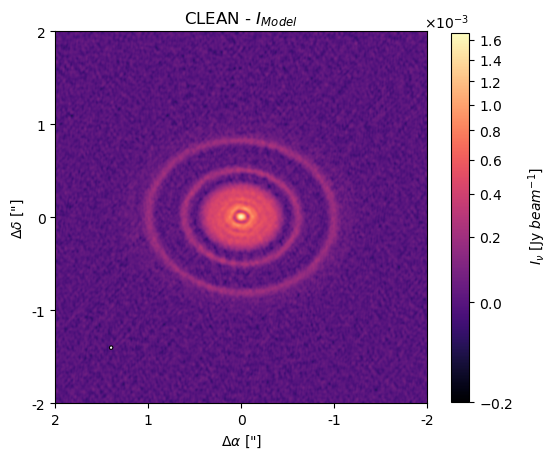

In [155]:
image_data = np.squeeze(fits_image[0].data)

pix_scale = np.round(abs(fits_image[0].header['CDELT1']) * 3600, 6)  # arcsec/pixel
bmaj_as = np.radians(fits_image[0].header['bmaj']) * 206265  # arcsec
bmin_as = np.radians(fits_image[0].header['bmin']) * 206265  # arcsec
bpa_deg = fits_image[0].header['bpa']  # <-- en grados

# tamaño del beam en PIXELES
bmaj_px = bmaj_as / pix_scale
bmin_px = bmin_as / pix_scale

center = len(image_data)/2.
arcsec_to_px = 1/pix_scale  # px por arcsec

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(
    image_data, origin='lower', cmap='magma',
    norm=colors.PowerNorm(gamma=0.45)
)

# ventana de ±2"
ax.set_xlim(center-2*arcsec_to_px, center+2*arcsec_to_px)
ax.set_ylim(center-2*arcsec_to_px, center+2*arcsec_to_px)

# coloca el beam dentro del cuadro, p.ej. en la esquina inferior izquierda del recorte
x0 = ax.get_xlim()[0] + 0.15*(ax.get_xlim()[1]-ax.get_xlim()[0])
y0 = ax.get_ylim()[0] + 0.15*(ax.get_ylim()[1]-ax.get_ylim()[0])

beam = Ellipse(
    (x0, y0),
    width=bmaj_px, height=bmin_px, angle=bpa_deg,  # ángulo en GRADOS
    facecolor='white', edgecolor='black', linewidth=0.8,
    zorder=5  # sobre la imagen
)

ax.add_patch(beam)  # <-- usar add_patch

# ticks y etiquetas como ya tenías...
ticks_x = [center-2*arcsec_to_px, center-1*arcsec_to_px, center, center+1*arcsec_to_px, center+2*arcsec_to_px]
ticks_y = [center-2*arcsec_to_px, center-1*arcsec_to_px, center, center+1*arcsec_to_px, center+2*arcsec_to_px]

cbar = fig.colorbar(im, shrink=0.8)
cbar.set_label(r' $I_{\nu}$ [Jy $beam^{-1}$]', rotation=90, labelpad=10)
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0)) 
cbar.ax.yaxis.set_major_formatter(formatter)


ax.set_xticks(ticks_x); ax.set_yticks(ticks_y)
ax.set_xticklabels([2,1,0,-1,-2]); ax.set_yticklabels([-2,-1,0,1,2])
ax.set_xlabel(r'$\Delta\alpha$ ["]'); ax.set_ylabel(r'$\Delta\delta$ ["]')
ax.set_title(r'CLEAN - $I_{Model}$')

plt.show()


Para un haz gaussiano con FWHM mayor y menor θmaj,θmin (en radianes): 

$Ω_{beam}  =  \frac{π}{4ln⁡2} θ_{maj} θ_{min} [sr]$

y la conversión es

$I_{ν}$  [Jy/sr]  =  $I_{ν}$  [Jy/beam] / $Ω_{beam}$.


Si tus FWHM están en arcsec, pasa a radianes con

θ[rad]=θ[′′]×π/(180×3600)


In [152]:
rad_to_arcsec = 3600 * 180 / np.pi

In [153]:
str_to_beam = np.pi/(4*np.log(2.)) * bmaj_as * bmin_as* (1/rad_to_arcsec)**2

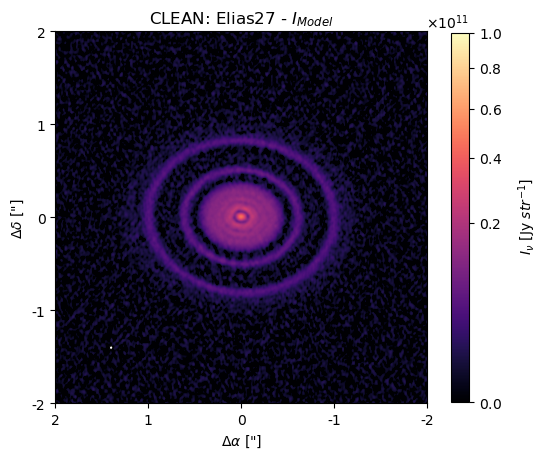

In [154]:
fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(
    image_data/str_to_beam, origin='lower', cmap='magma',
    norm=colors.PowerNorm(gamma=0.45, vmin=0, vmax= 1e11)
)

# ventana de ±2"
ax.set_xlim(center-2*arcsec_to_px, center+2*arcsec_to_px)
ax.set_ylim(center-2*arcsec_to_px, center+2*arcsec_to_px)

# coloca el beam dentro del cuadro, p.ej. en la esquina inferior izquierda del recorte
x0 = ax.get_xlim()[0] + 0.15*(ax.get_xlim()[1]-ax.get_xlim()[0])
y0 = ax.get_ylim()[0] + 0.15*(ax.get_ylim()[1]-ax.get_ylim()[0])

beam = Ellipse(
    (x0, y0),
    width=bmaj_px, height=bmin_px, angle=bpa_deg,  # ángulo en GRADOS
    facecolor='white', edgecolor='black', linewidth=0.8,
    zorder=5  # sobre la imagen
)

ax.add_patch(beam)  # <-- usar add_patch

# ticks y etiquetas como ya tenías...
ticks_x = [center-2*arcsec_to_px, center-1*arcsec_to_px, center, center+1*arcsec_to_px, center+2*arcsec_to_px]
ticks_y = [center-2*arcsec_to_px, center-1*arcsec_to_px, center, center+1*arcsec_to_px, center+2*arcsec_to_px]

cbar = fig.colorbar(im, shrink=0.8)
cbar.set_label(r' $I_{\nu}$ [Jy $str^{-1}$]', rotation=90, labelpad=10)
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0)) 
cbar.ax.yaxis.set_major_formatter(formatter)


ax.set_xticks(ticks_x); ax.set_yticks(ticks_y)
ax.set_xticklabels([2,1,0,-1,-2]); ax.set_yticklabels([-2,-1,0,1,2])
ax.set_xlabel(r'$\Delta\alpha$ ["]'); ax.set_ylabel(r'$\Delta\delta$ ["]')
ax.set_title(r'CLEAN $I_{Model}$')

plt.show()


## FRANK2D

In [157]:
import pickle
file = open(dir + 'frank2d_AS209_250.pickle', 'rb')
disk = pickle.load(file)
file.close()

file = open(dir + 'geom_AS209.pickle', 'rb')
disk_geom = pickle.load(file)
file.close()

In [158]:
Plot_ = Plot(disk, disk_geom)

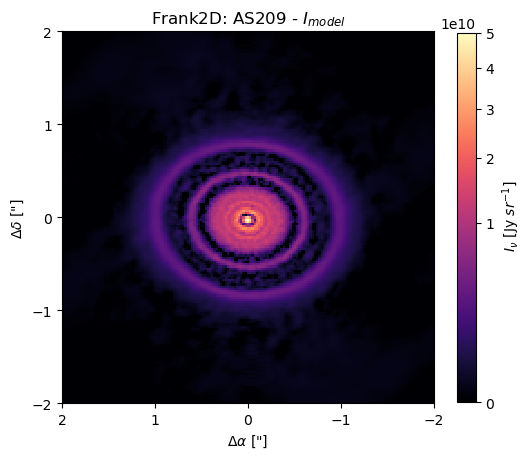

In [168]:
I, X, Y = Plot_.intensity_model(title = r'Frank2D: AS209 - $I_{model}$', vmax = 5e10)

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_50580/3644723826.py:122: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


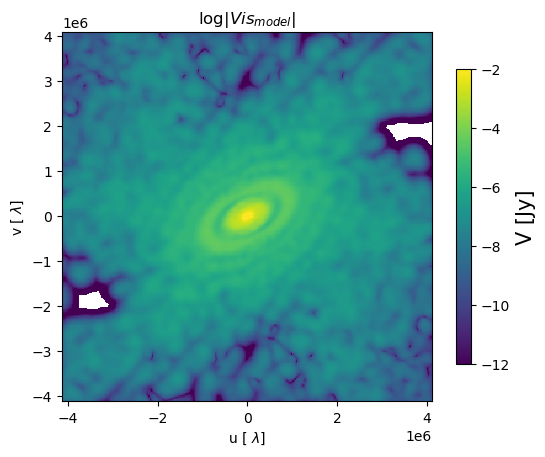

In [113]:
Plot_.visibility_model()

/var/folders/ng/vs__trg57hl3mtgq5kgkzj4h0000gn/T/ipykernel_50580/3644723826.py:149: RuntimeWarning: divide by zero encountered in log
  np.log(np.abs(vis_shifted)),


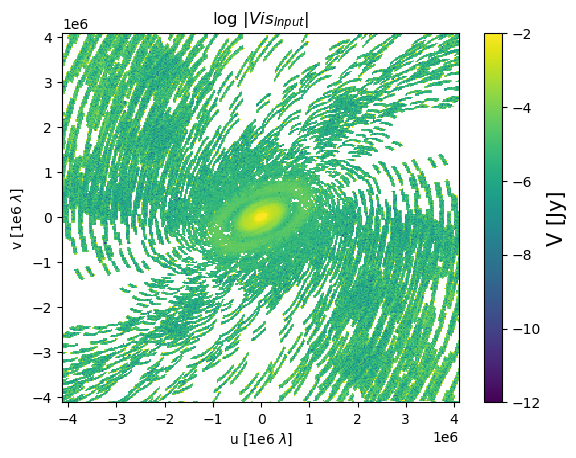

In [114]:
Plot_.visibility_gridded_input()

## FRANK2D CONVOLUTED

In [72]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from skimage.transform import resize
from radio_beam import Beam
from scipy.ndimage import zoom
from astropy.convolution import convolve_fft

In [126]:
# --- ENTRADAS ---
clean_fits = "clean_image.fits"     # tu imagen CLEAN (Jy/beam)
model2d = I.astype(float)  # tu matriz 2D (numpy array), misma forma que CLEAN si es posible
model_units = "Jy/sr"               # pon "Jy/sr" si tu modelo es físico; "arb" si es adimensional


# 1) Header y beam de la CLEAN
hdul = fits.open(fits_name)
clean_hdr = hdul[0].header
clean_data = hdul[0].data.squeeze()   # Jy/beam
beam = Beam.from_fits_header(clean_hdr)
Omega = beam.sr  # steradians

In [127]:
target_shape

(4000, 4000)

In [142]:
target_shape = 2000, 2000 #clean_data.shape
ny0, nx0 = model.shape
ny, nx   = 2000, 2000

In [143]:
# Remuestreo al mismo shape manteniendo rangos (mismo FOV)
I_resampled = resize(
    model2d, target_shape,
    order=3,               # cúbico (suave); usa order=1 si prefieres más robusto
    mode="edge",
    anti_aliasing=True,
    preserve_range=True
)

# Remuestreo al mismo shape manteniendo rangos (mismo FOV)
X_resampled = resize(
    X, target_shape,
    order=3,               # cúbico (suave); usa order=1 si prefieres más robusto
    mode="edge",
    anti_aliasing=True,
    preserve_range=True
)

# Remuestreo al mismo shape manteniendo rangos (mismo FOV)
Y_resampled = resize(
    Y, target_shape,
    order=3,               # cúbico (suave); usa order=1 si prefieres más robusto
    mode="edge",
    anti_aliasing=True,
    preserve_range=True
)

In [140]:

# Si el modelo estaba en Jy/pixel y quieres conservar flujo total,
# corrige por el cambio de área de píxel (mismo FOV => área por píxel ~ 1/(nx*ny)).
if model_units.lower() == "jy/pixel":
    area_ratio = (nx0 * ny0) / (nx * ny)   # A_pix_old / A_pix_new
    I_resampled *= area_ratio

# --- 2) Convolución con el restoring beam ---
beam = Beam.from_fits_header(clean_hdr)    # usa BMAJ/BMIN/BPA

# Tamaño de píxel (para el kernel, en arcsec)
pixscale = np.abs(clean_hdr["CDELT2"]) * u.deg
kernel = beam.as_kernel(pixscale.to(u.arcsec))

model_conv = convolve_fft(I_resampled, kernel.array)

In [138]:
I = Plot_.given_intensity_model(model_conv, 2000, X_resampled, Y_resampled, title = r'Frank2D - $I_{model}$ convoluted')

ValueError: cannot reshape array of size 16000000 into shape (2000,2000)

<Figure size 600x600 with 0 Axes>

In [129]:
model_conv2 = convolve_fft(I, kernel.array)

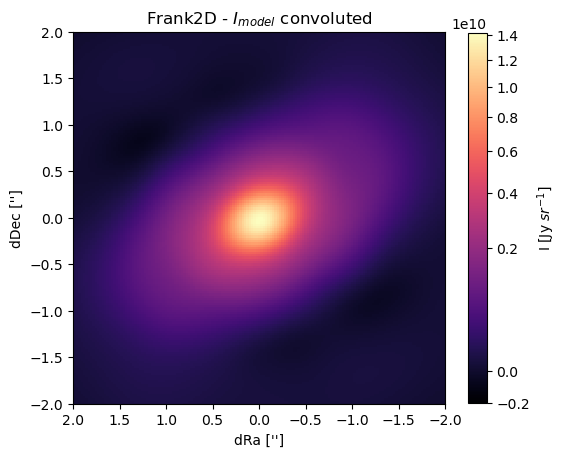

In [130]:
Plot_.given_intensity_model(model_conv2, 300, X, Y, title = r'Frank2D - $I_{model}$ convoluted')

## Comparing profiles

### CLEAN

In [38]:
# Obtain the radial profiles convolved to a circular beam.
from gofish import imagecube

infile_1mm = fits_name
#2D->1D
cube_1mm = imagecube(infile_1mm)
inc, pa, dra, ddec = data['inc'], data['pa'], data['dra'], data['ddec']
x_1mm,y_1mm,dy_1mm = cube_1mm.radial_profile(inc= data['inc'], PA=data['pa'], x0=data['dra'], y0=data['ddec'])

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


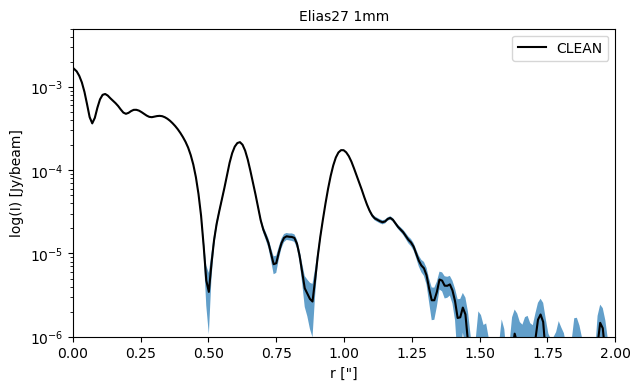

In [39]:
plt.figure(figsize=(7, 4))
plt.plot(x_1mm, y_1mm, "black", label = "CLEAN")
plt.fill_between(x_1mm, y_1mm-dy_1mm, y_1mm+dy_1mm,alpha=0.7)
plt.title(r'Elias27 1mm', size=10)
plt.ylabel("log(I) [Jy/beam]", size=10)
plt.xlabel('r ["]', size=10)
plt.legend(fontsize=10)
plt.yscale('log')
plt.ylim(1e-6, 0.5e-2)
plt.xlim(0, 2)
plt.show()

### F1D

In [16]:
disk._gridded_data

{'u': array([     0.        ,      0.        ,      0.        , ...,
        -34377.46770785, -34377.46770785, -34377.46770785]),
 'v': array([      0.        ,   34377.46770785,   68754.9354157 , ...,
        -103132.40312355,  -68754.9354157 ,  -34377.46770785]),
 'vis': array([0.25666707-0.j        , 0.23617999-0.00010499j,
        0.18739348+0.00026636j, ..., 0.12153548-0.00053001j,
        0.16627102-0.00069134j, 0.2056068 -0.0007439j ]),
 'weights': array([1.33284608e+08, 3.74317009e+08, 1.55269785e+08, ...,
        8.93065101e+07, 2.22029716e+08, 2.55321007e+08])}

In [17]:
u, v, Vis, Weights = disk._gridded_data['u'], disk._gridded_data['v'], disk._gridded_data['vis'], disk._gridded_data['weights']

In [18]:
# Frank Parameters
n_pts = 300
alpha = 1.3
w_smooth = 1e-4
Rout = 2

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(Rout, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u, v, Vis, Weights)

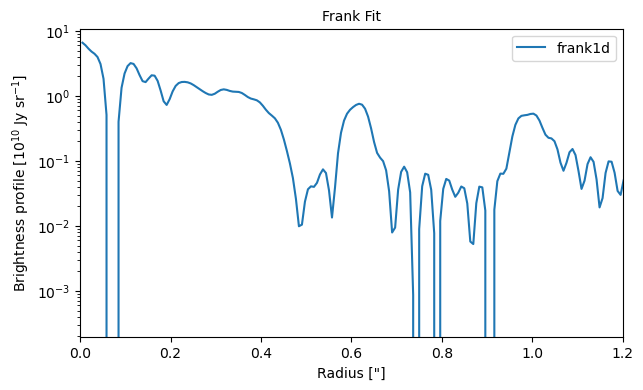

In [19]:
plt.figure(figsize = (7, 4))
plt.plot(sol.r, sol.mean/1e10,label ='frank1d')
plt.xlabel('Radius ["]', size = 10)
plt.ylabel(r'Brightness profile [$10^{10}$ Jy sr$^{-1}$]', size = 10)
plt.title('Frank Fit', size = 10)
plt.xlim(0, 1.2)
plt.yscale('log')
plt.legend()
plt.show()

### F2D

In [20]:
from scipy.stats import binned_statistic

def get_radial_profile_deprojected(frank_object, bins, range = None):
    x = frank_object._FT._Xn*rad_to_arcsec
    y = frank_object._FT._Yn*rad_to_arcsec

    inc_r = frank_object._Geometry._inc*deg_to_rad
    pa_r = (frank_object._Geometry._pa)*deg_to_rad

    cos_i = np.cos(inc_r)
    cos_pa, sin_pa = np.cos(pa_r), np.sin(pa_r)

    x_d = (x * cos_pa + y * sin_pa) / cos_i
    y_d = (x *-sin_pa + y * cos_pa)

    
    r = np.hypot(x_d, y_d)
    I = frank_object.sol_intensity
    r = r.flatten()
    I = I.flatten()
    I_binned, bin_edges, _ = binned_statistic(r, I, 'mean', bins = bins, range = range)
    r_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    return r_centers, I_binned

In [21]:
dr = (sol.r[1] - sol.r[0])/2
bins_frank1d = np.append(sol.r - dr, [sol.r[-1] + dr])
len_bins = len(sol.r)
range = (sol.r.min(), sol.r.max())

centers = np.geomspace(sol.r.min(), sol.r.max(), num=80)
edges = np.zeros(len(centers) + 1)
edges[1:-1] = np.sqrt(centers[:-1] * centers[1:])
edges[0] = centers[0]**2 / edges[1]
edges[-1] = centers[-1]**2 / edges[-2]

In [22]:
sol.r.min()

0.005090471437256382

In [23]:
r_f2d, I_f2d = get_radial_profile_deprojected(disk, 100, range)

In [24]:
#np.where(np.isnan(Elias27.sol_intensity) == True)

In [25]:
#np.sort((np.hypot(Elias27._FT._x, Elias27._FT._y)*rad_to_arcsec))

In [26]:
I_f2d /= np.cos(inc*deg_to_rad)

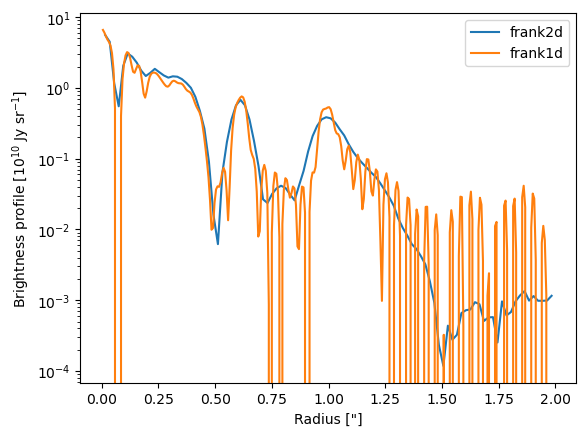

In [27]:
plt.plot(r_f2d, I_f2d/1e10, label = "frank2d")
plt.plot(sol.r, sol.mean/1e10,label ='frank1d')
plt.xlabel('Radius ["]', size = 10)
plt.ylabel(r'Brightness profile [$10^{10}$ Jy sr$^{-1}$]', size = 10)
plt.yscale('log')
plt.legend()
plt.show()

In [28]:
from frank.utilities import convolve_profile

clean_beam_1mm = {'bmaj': bmaj_as, 'bmin': bmin_as, 'beam_pa': bpa_deg}
area_1mm = clean_beam_1mm['bmaj']*clean_beam_1mm['bmin']*np.pi/4./np.log(2.)*(1/rad_to_arcsec)**2

convolved_1mm_frank1d = convolve_profile(sol.r, sol.mean, inc, pa, clean_beam_1mm)*area_1mm
convolved_1mm_frank2d = convolve_profile(r_f2d, I_f2d, inc, pa, clean_beam_1mm)*area_1mm

In [29]:
convolved_1mm_frank2d

array([1.32409551e-03, 1.15881357e-03, 6.73478028e-04, 5.04493317e-04,
       7.37301938e-04, 9.66655509e-04, 9.66949820e-04, 8.26498966e-04,
       6.78299444e-04, 6.02426131e-04, 6.12942758e-04, 6.36604277e-04,
       6.11090260e-04, 5.63578117e-04, 5.35531675e-04, 5.29751975e-04,
       5.17814763e-04, 4.83055897e-04, 4.28712551e-04, 3.58150917e-04,
       2.71523028e-04, 1.81511782e-04, 1.03985922e-04, 4.70402265e-05,
       1.69134626e-05, 1.31373231e-05, 3.31019516e-05, 7.52957083e-05,
       1.35296208e-04, 1.93930915e-04, 2.19182963e-04, 1.93245110e-04,
       1.34743092e-04, 7.67318689e-05, 3.70851114e-05, 1.69681557e-05,
       1.09848217e-05, 1.16882837e-05, 1.35548621e-05, 1.43871374e-05,
       1.36070522e-05, 1.20715518e-05, 1.24699277e-05, 1.77222608e-05,
       2.97543464e-05, 5.02720831e-05, 7.73058225e-05, 1.05024012e-04,
       1.26537889e-04, 1.35993066e-04, 1.31933233e-04, 1.17186882e-04,
       9.76899034e-05, 7.85267702e-05, 6.14387952e-05, 4.81232689e-05,
      

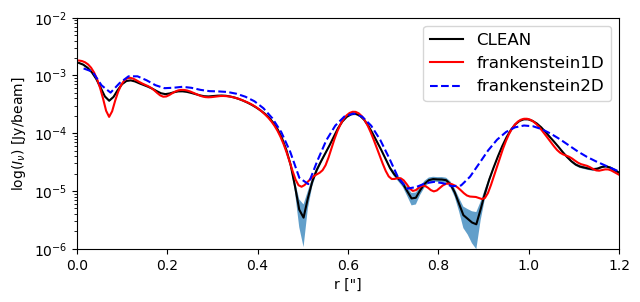

In [30]:
plt.figure(figsize=(7, 3))
plt.plot(x_1mm, y_1mm, "black", label = "CLEAN")
plt.fill_between(x_1mm, y_1mm-dy_1mm, y_1mm+dy_1mm,alpha=0.7)
plt.plot(sol.r, convolved_1mm_frank1d, "red", label=r'frankenstein1D')
plt.plot(r_f2d,convolved_1mm_frank2d, "blue", ls= '--', label=r'frankenstein2D')
plt.ylabel(r'log($I_\nu$) [Jy/beam]', size=10)
plt.xlabel('r ["]', size=10)
plt.legend(fontsize=12)
plt.yscale('log')
plt.ylim(1e-6, 1e-2)
plt.xlim(0,1.2)
plt.show()